<a href="https://colab.research.google.com/github/HimanshuSingh0912/MedicalCostPrediction/blob/main/MedicalCostPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Medical Cost Prediction - Linear Regression Model


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score

1. Load Dataset

In [ ]:

insurance_df = pd.read_csv('/content/insurance (1).csv')
print('Shape:', insurance_df.shape)
insurance_df.head()

Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:

insurance_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:

insurance_df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


2. Data Cleaning and Preprocessing

In [ ]:
# Check null counts
print('Null values before treatment:')
print(insurance_df.isnull().sum())

Null values before treatment:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


Label Encoding (Categorical → Numeric)

In [ ]:
le = LabelEncoder()
cat_cols_insurance = insurance_df.select_dtypes(include='object').columns.tolist()
print('Categorical columns:', cat_cols_insurance)

for col in cat_cols_insurance:
    insurance_df[col] = le.fit_transform(insurance_df[col].astype(str))

insurance_df.head()

Categorical columns: ['sex', 'smoker', 'region']


,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


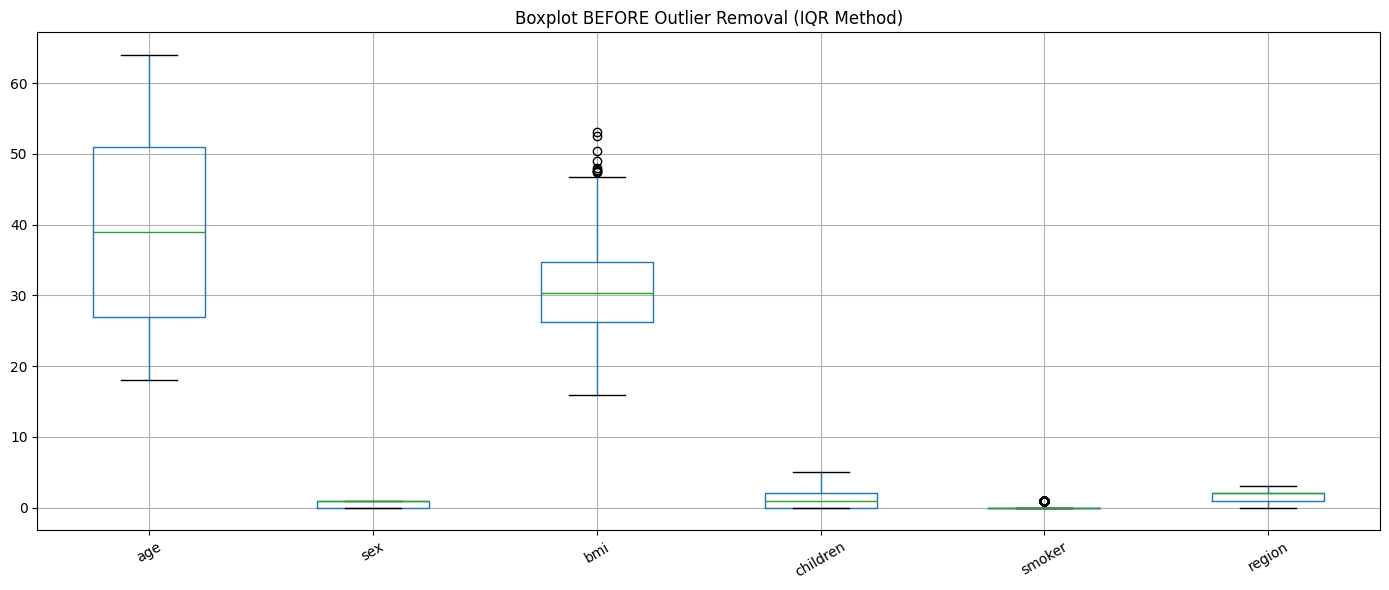

In [ ]:
num_cols_insurance = insurance_df.select_dtypes(include=np.number).columns.tolist()
num_cols_insurance = [c for c in num_cols_insurance if c != 'charges']

# ---- BEFORE Boxplot ----
plt.figure(figsize=(14, 6))
insurance_df[num_cols_insurance].boxplot(rot=30)
plt.title('Boxplot BEFORE Outlier Removal (IQR Method)')
plt.tight_layout()
plt.show()

In [ ]:
print('Rows before outlier removal:', len(insurance_df))

for col in num_cols_insurance:
    Q1 = insurance_df[col].quantile(0.25)
    Q3 = insurance_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    insurance_df = insurance_df[(insurance_df[col] >= lower) & (insurance_df[col] <= upper)]

print('Rows after outlier removal:', len(insurance_df))

Rows before outlier removal: 1338
Rows after outlier removal: 1058


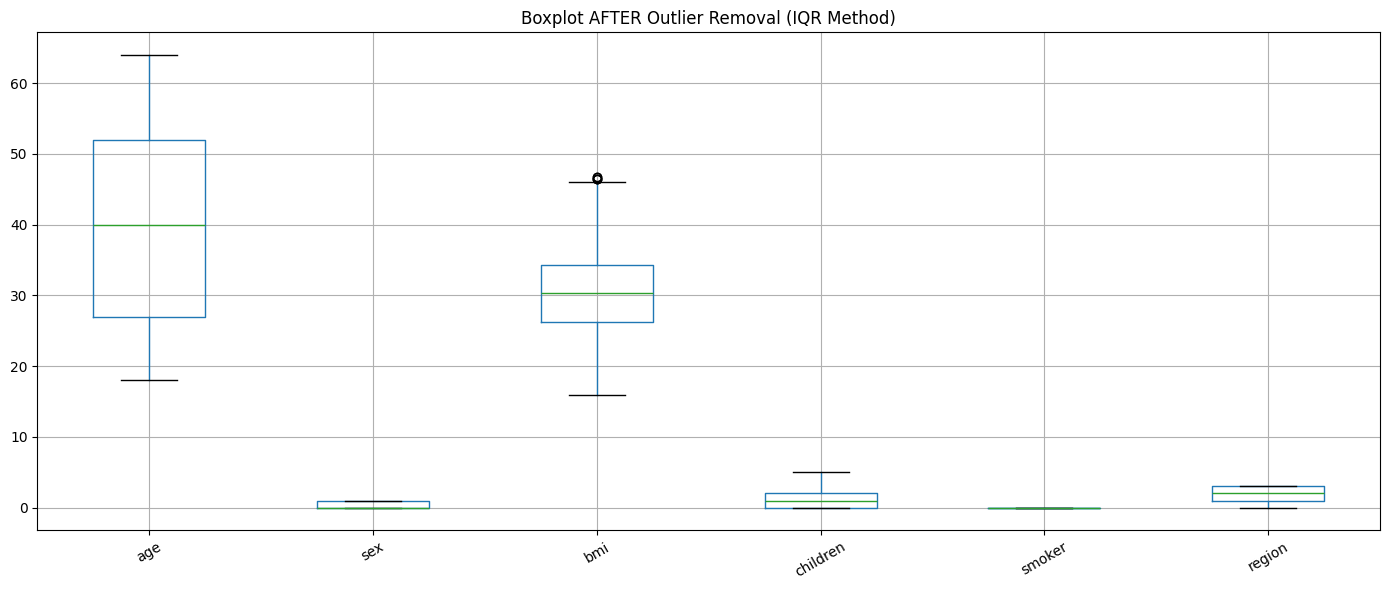

In [ ]:
# ---- AFTER Boxplot ----
plt.figure(figsize=(14, 6))
insurance_df[num_cols_insurance].boxplot(rot=30)
plt.title('Boxplot AFTER Outlier Removal (IQR Method)')
plt.tight_layout()
plt.show()

3. Visualizations

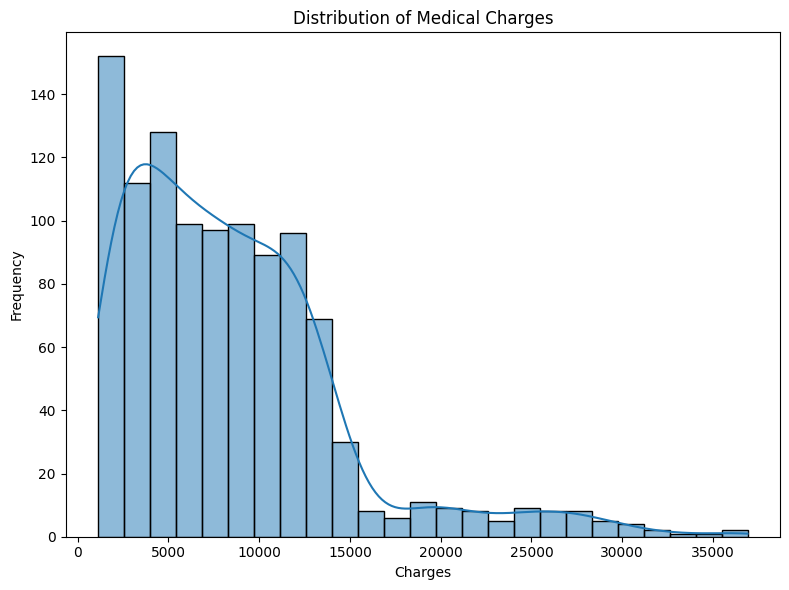

In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(insurance_df['charges'], kde=True)
plt.title('Distribution of Medical Charges')
plt.xlabel('Charges')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

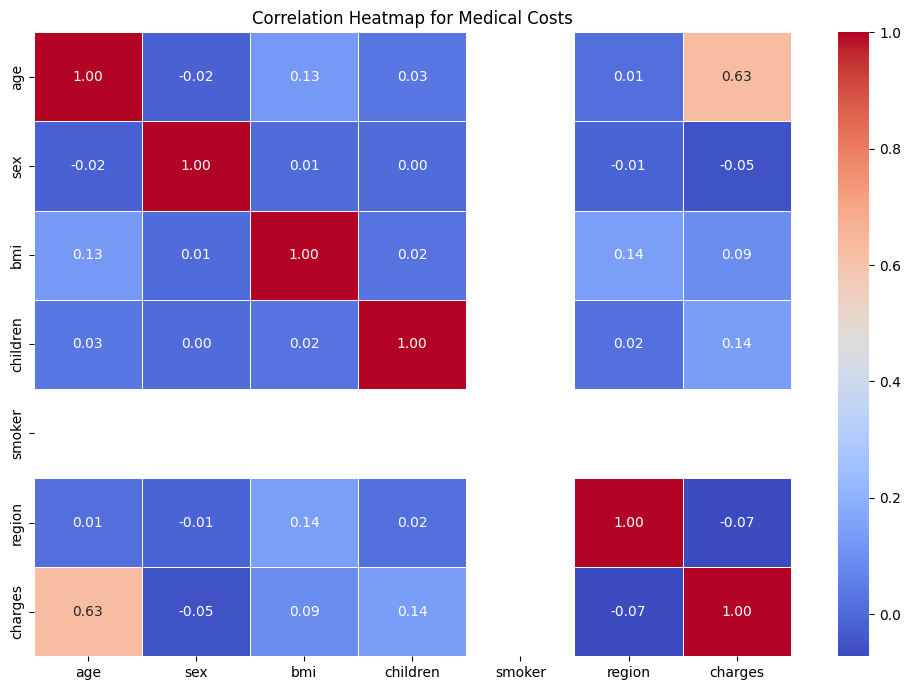

In [ ]:
plt.figure(figsize=(10, 7))
corr_insurance = insurance_df.corr()
sns.heatmap(corr_insurance, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap for Medical Costs')
plt.tight_layout()
plt.show()

4. Model Training - Linear Regression

In [ ]:
# Define features (X_insurance) and target (y_insurance)
X_insurance = insurance_df.drop(columns=['charges'])
y_insurance = insurance_df['charges']

# Split into train and test sets (80/20)
X_train_insurance, X_test_insurance, y_train_insurance, y_test_insurance = train_test_split(
    X_insurance, y_insurance, test_size=0.2, random_state=42
)

print('Insurance Train size:', X_train_insurance.shape)
print('Insurance Test size :', X_test_insurance.shape)

# Train Linear Regression model (Logistic Regression is for classification, Linear is for regression)
insurance_model = LinearRegression()
insurance_model.fit(X_train_insurance, y_train_insurance)

Insurance Train size: (846, 6)
Insurance Test size : (212, 6)


LinearRegression()

Mean Absolute Error (MAE): 2591.12
Mean Squared Error (MSE): 22399566.52
Root Mean Squared Error (RMSE): 4732.82
R-squared (R2): 0.3425


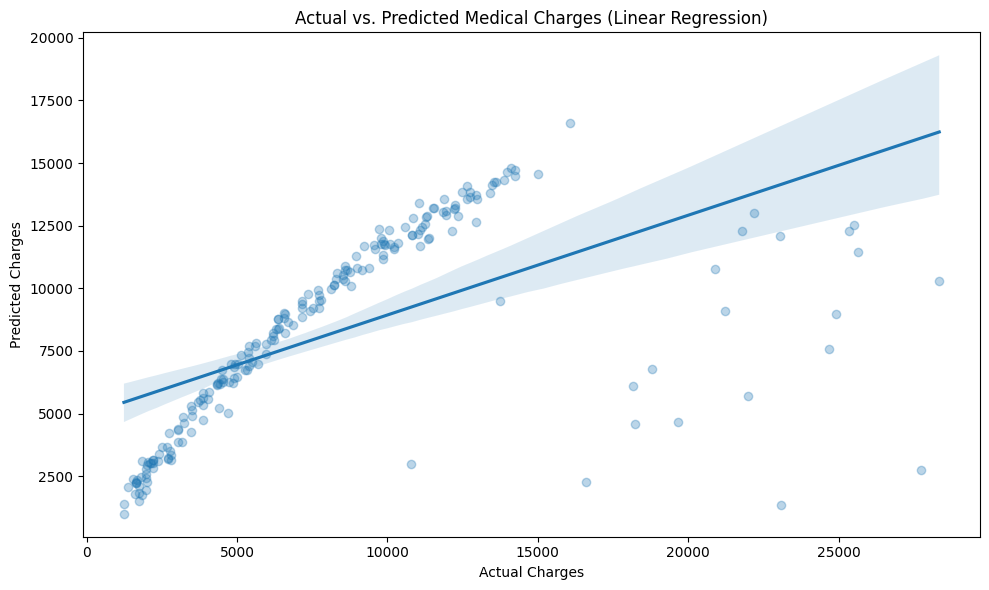

In [ ]:
y_pred_insurance = insurance_model.predict(X_test_insurance)

# Evaluate Regression Model
mae = mean_absolute_error(y_test_insurance, y_pred_insurance)
mse = mean_squared_error(y_test_insurance, y_pred_insurance)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_insurance, y_pred_insurance)

print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')
print(f'R-squared (R2): {r2:.4f}')

# Visualize Predictions vs Actual
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test_insurance, y=y_pred_insurance, scatter_kws={'alpha':0.3})
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs. Predicted Medical Charges (Linear Regression)')
plt.tight_layout()
plt.show()